# UDD ablation wiring — end-to-end verification (no GPU needed)

This notebook checks that the **public-data ablation changes** work as intended before any GPU is
spent, exercising the real scripts (not reimplementations):

1. corpus + new schema sanity (native `instructions`/`answers` lists, `fold`, derived columns)
2. FULL training pools (7 tasks incl. grounding-format localization + derived A2 rationales
   + fine-grained text probes; equal-N control applied per arm family at compose time)
3. arm composition dry-run (the A1–A6 mixes) + **leakage check** (no heldout image in any arm)
4. A2 factor inspection: rationale-chain vs answer-only control on the same record
   — and 4b: the fine-grained reading probes ("what is the 3rd character?") derived from gold text
5. mock multi-model evaluation through the real metric dispatch (sanity: oracle≈1, constant≈0)
6. *(GPU-gated)* actually run the arms
7. read per-arm capability scores
8.–10. the **full comparison**: every arm scored on the ENTIRE suite before AND after training —
   coarse per-suite table, fine-grained per-axis heatmap, and the per-sample examples that flipped

Runs **locally** (uses the merged corpus at `data/udd/hf/_all`, build with
`python scripts/build_udd.py --per-bench 300`) **or on Colab from scratch** — the setup cell
clones [SangbumChoi/OCR](https://github.com/SangbumChoi/OCR), installs it, and streams the public
corpus release from the Hub ([`danelcsb/UDD`](https://huggingface.co/datasets/danelcsb/UDD)) when
no local build exists.


In [1]:
# --- setup: local repo OR fresh Colab (clone + install); corpus: local build OR the Hub ---
import importlib, json, os, subprocess, sys
from pathlib import Path

def _repo_root():
    for c in (Path.cwd(), Path.cwd().parent):
        if (c / "pyproject.toml").exists():
            return c
    return None

ROOT = _repo_root()
if ROOT is None:                       # fresh environment (Colab/Kaggle): clone + install
    subprocess.run(["git", "clone", "https://github.com/SangbumChoi/OCR.git"], check=False)
    ROOT = Path("OCR").resolve()
    subprocess.run(["git", "-C", str(ROOT), "checkout", "claude/new-session-w79q0i"], check=False)
    subprocess.run(["git", "-C", str(ROOT), "pull", "--ff-only"], check=False)
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                        f"{ROOT}[models,finetune]"], capture_output=True, text=True)
    if r.returncode != 0:                      # a silent install failure breaks section 6 later
        print("[bootstrap] editable install FAILED:\n", (r.stderr or r.stdout)[-1500:])
os.chdir(ROOT); ROOT = Path.cwd()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
importlib.invalidate_caches()

# corpus: prefer the local merged build; else stream the public release from the Hub (Colab path)
from collections import Counter
from datasets import load_from_disk, load_dataset
LOCAL_ALL, UDD_REPO = ROOT / "data/udd/hf/_all", "danelcsb/UDD"
if LOCAL_ALL.exists():
    ds, UDD_SRC_ARGS = load_from_disk(str(LOCAL_ALL)), ["--src", str(LOCAL_ALL)]
else:
    ds, UDD_SRC_ARGS = load_dataset(UDD_REPO, split="train"), ["--repo", UDD_REPO]
print(f"corpus: {len(ds)} image-rows, {len(ds.column_names)} columns "
      f"[{'local build' if LOCAL_ALL.exists() else 'Hub: ' + UDD_REPO}]")
assert "instructions" in ds.column_names and "qas_json" not in ds.column_names
print("tasks:", dict(Counter(ds["task"]).most_common()))
print("fold:", dict(Counter(ds["fold"])))
print("languages:", dict(Counter(ds["language"]).most_common(6)))
multi = sum(1 for q in ds["instructions"] if len(q) > 1)
print(f"multi-QA image-rows: {multi} (native lists; pairing enforced at build)")
from docvlm_eval.unified.hf import validate_payload_shapes
validate_payload_shapes(ds); print("validate_payload_shapes: PASS")


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corpus: 39837 image-rows, 21 columns [local build]


tasks: {'vqa': 15133, 'recognition': 8994, 'reasoning': 8148, 'localization': 2952, 'kie': 1650, 'table': 1500, 'classification': 1460}


fold: {'train': 35883, 'heldout': 3954}


languages: {'en': 32409, 'und': 2999, 'ko': 1616, 'zh': 1331, 'ja': 263, 'de': 233}


multi-QA image-rows: 10904 (native lists; pairing enforced at build)


validate_payload_shapes: PASS


## 1. Build the training pools (tasks + languages + derived A2 pair — FULL pools)

`--per-task -1` writes each task/language pool **uncapped** (all train-fold images): the equal-N
control the ablation needs is applied later, per arm family, by `run_udd_ablation` (its
`--count 0` default trains every family at the largest equal-N all of its arms can support).


In [2]:
# UDD_SRC_ARGS (from the setup cell) points the builders at the local corpus or the Hub release.
# Language pools are CAPPED: the A4 budget is the SMALLEST language pool, so uncapped en/zh pools
# would only cost gigabytes of decoded images without changing any arm's equal-N.
for args in (["--per-task", "-1", "--merge-qa", "--derive-spatial-reasoning", "--derive-text-probes"],
             ["--out", "data/udd_langs", "--group-by", "language", "--per-task", "2000"]):
    r = subprocess.run([sys.executable, "scripts/build_task_trainsets.py", *args, *UDD_SRC_ARGS],
                       cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-600:]); assert r.returncode == 0, r.stderr[-500:]


images=2664
[ok]   reasoning      available=34666 used=34666 images=11247
[ok]   recognition    available=12451 used=12451 images=8098
[ok]   table          available=1338 used=1338 images=1338
[ok]   vqa            available=30804 used=30804 images=13699
[ok]   heldout: 8170 samples (classification, kie, localization, reasoning, recognition, table, vqa) -> heldout_*.jsonl

=== built 7 per-task sets (full pools) -> /home/user/OCR/data/udd_tasks ===
  jsonl : /home/user/OCR/data/udd_tasks/task_<task>.jsonl   (feed to run_task_value.py)
  mixed control  : /home/user/OCR/data/udd_tasks/all.jsonl




[ok]   ru             available= 478 used= 478 images=169
[ok]   th             available=   8 used=   8 images=5
[ok]   und            available=2695 used=2000 images=2000
[ok]   vi             available= 677 used= 677 images=194
[ok]   zh             available=1204 used=1204 images=1204
[ok]   heldout: 8170 samples (classification, kie, localization, reasoning, recognition, table, vqa) -> heldout_*.jsonl

=== built 13 per-language sets (N=2000 each) -> data/udd_langs ===
  jsonl : data/udd_langs/lang_<language>.jsonl   (feed to run_task_value.py)
  mixed control  : data/udd_langs/all.jsonl



## 2. Compose the full A1–A6 arm ladder

**With a GPU there is no separate dry-run** — section 6 composes and trains every arm for real.
The `--dry-run` (compose + inspect, no training) is the wiring proof for CPU boxes only.


In [3]:
import importlib.util
has_gpu = False
if importlib.util.find_spec("torch"):
    import torch; has_gpu = torch.cuda.is_available()

if has_gpu:
    print("GPU detected — skipping the dry-run: section 6 composes + trains ALL arms directly.")
else:
    r = subprocess.run([sys.executable, "scripts/run_udd_ablation.py",
                        "--arm", "A1", "A2", "A3", "A4", "A5", "A6", "--dry-run"],
                       cwd=ROOT, capture_output=True, text=True)
    print(r.stdout); assert r.returncode == 0, r.stderr[-500:]


[udd-ablation] 24 arm runs, N=auto (ALL images, equal per family): {'A1': 2964, 'A2': 10870, 'A3': 2964, 'A4': 178, 'A5': 5928, 'A6': 5928}, heldout=yes

[1/24] A1_spotting_on: 2964 samples (target 2964) <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + task_localization.jsonl×0.33
[2/24] A1_spotting_off: 2964 samples (target 2964) <- task_vqa.jsonl×0.50 + task_kie.jsonl×0.50
[3/24] A2_reason_chain: 10870 samples (target 10870) <- derived_reasoning_chain.jsonl×1.00
[4/24] A2_reason_answer: 10870 samples (target 10870) <- derived_reasoning_answer.jsonl×1.00
[5/24] A3_base: 2964 samples (target 2964) <- task_vqa.jsonl×0.50 + task_kie.jsonl×0.50
[6/24] A3_spot: 2964 samples (target 2964) <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + task_localization.jsonl×0.33
[7/24] A3_reason: 2964 samples (target 2964) <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + derived_reasoning_chain.jsonl×0.33
[8/24] A3_spot_reason: 2964 samples (target 2964) <- task_vqa.jsonl×0.25 + task_kie.jsonl×0.25 + task_loca

## 3. Leakage check — no heldout image may appear in ANY arm's training mix

In [4]:
arms_dir = ROOT / "data/udd_tasks/arms"
if not list(arms_dir.glob("*.jsonl")):        # GPU path skipped section 2 — compose quietly
    subprocess.run([sys.executable, "scripts/run_udd_ablation.py",
                    "--arm", "A1", "A2", "A3", "A4", "A5", "A6", "--dry-run"],
                   cwd=ROOT, capture_output=True, text=True, check=True)

heldout_imgs = set()
for f in (ROOT / "data/udd_tasks").glob("heldout_*.jsonl"):
    for ln in f.read_text().splitlines():
        heldout_imgs.add(json.loads(ln)["image_path"])
leaks = 0
for arm in sorted((ROOT / "data/udd_tasks/arms").glob("*.jsonl")):
    hit = sum(1 for ln in arm.read_text().splitlines()
              if json.loads(ln)["image_path"] in heldout_imgs)
    print(f"{arm.stem:20} train_rows_using_heldout_images={hit}")
    leaks += hit
assert leaks == 0, f"LEAK: {leaks} heldout images in training arms"
print("leakage check: PASS (fold split is image-keyed and respected by every arm)")

A1_spotting_off      train_rows_using_heldout_images=0
A1_spotting_on       train_rows_using_heldout_images=0


A2_reason_answer     train_rows_using_heldout_images=0
A2_reason_chain      train_rows_using_heldout_images=0
A3_base              train_rows_using_heldout_images=0


A3_reason            train_rows_using_heldout_images=0
A3_spot              train_rows_using_heldout_images=0
A3_spot_reason       train_rows_using_heldout_images=0
A4_en                train_rows_using_heldout_images=0
A4_en_ar             train_rows_using_heldout_images=0
A4_en_de             train_rows_using_heldout_images=0
A4_en_fr             train_rows_using_heldout_images=0
A4_en_id             train_rows_using_heldout_images=0
A4_en_ja             train_rows_using_heldout_images=0
A4_en_ko             train_rows_using_heldout_images=0
A4_en_zh             train_rows_using_heldout_images=0


A5_connector         train_rows_using_heldout_images=0
A5_llm_attn          train_rows_using_heldout_images=0
A5_llm_mlp           train_rows_using_heldout_images=0
A5_vision            train_rows_using_heldout_images=0


A6_r16               train_rows_using_heldout_images=0
A6_r32               train_rows_using_heldout_images=0


A6_r64               train_rows_using_heldout_images=0
A6_r8                train_rows_using_heldout_images=0
leakage check: PASS (fold split is image-keyed and respected by every arm)


## 4. The A2 factor, isolated — rationale chain vs answer-only on the same element

In [5]:
chain = [json.loads(l) for l in (ROOT/"data/udd_tasks/derived_reasoning_chain.jsonl").read_text().splitlines()]
answer = [json.loads(l) for l in (ROOT/"data/udd_tasks/derived_reasoning_answer.jsonl").read_text().splitlines()]
assert len(chain) == len(answer), "A2 arm pair must have identical record counts"
by_id = {r["sample_id"]: r for r in answer}
ex = chain[0]; ctrl = by_id[ex["sample_id"]]
print("SAME element, two targets (the only difference = the rationale text):")
print(f"  chain  Q: {ex['question'][:80]}")
print(f"  chain  A: {ex['answers'][0][:160]}")
print(f"  answer Q: {ctrl['question'][:80]}")
print(f"  answer A: {ctrl['answers'][0][:160]}")

SAME element, two targets (the only difference = the rationale text):
  chain  Q: Where is the B-QUESTION located in the document? Explain how you find it.
  chain  A: Scanning the document layout, the I-QUESTION is a useful anchor. The B-QUESTION appears to the left of the I-QUESTION, in the middle-left of the page, reading '
  answer Q: Where is the B-QUESTION located in the document?
  answer A: The B-QUESTION is in the middle-left of the page.


## 4b. Fine-grained reading probes — instruction diversity from single-line crops

IAM/SROIE-style sources are cropped single sentences whose only instruction was "print the full
text". `derive_text_probes()` turns each gold string into **varied, fine-grained questions answered
by the string itself** — for "789417-W": *what is the 3rd character?* → `9`, *the first two
characters?* → `78`, plus last-word and word-count probes. Deterministic (seeded by sample id), no
model, exact-match metric; formula sources are excluded (character positions in LaTeX are
meaningless). `--derive-text-probes` (section 1) mixes them into the recognition pool.


In [6]:
from docvlm_eval.unified import derive_text_probes, unified_from_hf_row

# derive directly from corpus rows (display); the same function fed the section-1 build
shown = 0
for i in (i for i, s in enumerate(ds["source"]) if s in ("iam", "sroie")):
    row = {k: ds[k][i] for k in ds.column_names if k != "image"}
    rec = unified_from_hf_row(row, image_path="unused.jpg")
    ps = derive_text_probes(rec)
    if not ps:
        continue                                    # multi-line / too short-long rows yield none
    print(f"gold text: {(rec.full_text or rec.answers[0])!r}")
    for s in ps:
        print(f"   {s.question[:74]} -> {s.answers}")
    shown += 1
    if shown == 3:
        break

# and confirm they landed in the balanced recognition set
probes = [r for r in map(json.loads,
                         (ROOT / "data/udd_tasks/task_recognition.jsonl").read_text().splitlines())
          if r.get("answer_type") == "recognition:probe"]
print(f"\n{len(probes)} probe samples inside the equal-N recognition training set")
assert shown and probes, "text probes must derive from the corpus AND appear in the built set"


gold text: "I don't think he will storm the charts with this one , but it 's a good start ."
   What is the 5th character (ignoring spaces) in the image? Answer with that -> ["'"]
   What are the first two characters in the image? Answer with exactly those  -> ['Id']
   What is the last word in the image? Answer with that word only. -> ['start']
gold text: 'CHRIS CHARLES , 39 , who lives in Stockton-on-Tees , is an accountant .'
   What is the 6th character (ignoring spaces) in the image? Answer with that -> ['C']
   What are the first two characters in the image? Answer with exactly those  -> ['CH']
   What is the last word in the image? Answer with that word only. -> ['accountant']
gold text: '" My September Love , " the big David Whitfield hit of 1956 .'
   What is the 9th character (ignoring spaces) in the image? Answer with that -> ['m']
   What are the first two characters in the image? Answer with exactly those  -> ['"M']
   What is the last word in the image? Answer with that w


4353 probe samples inside the equal-N recognition training set


## 5. Mock multi-model evaluation (real metric dispatch, deterministic models)

No GPU means no real model — but the whole eval path (jsonl loading, per-task metric dispatch,
aggregation) can still be tested with **mock models: deterministic rules applied to the gold
answer or the question**. Because each rule is a *known behaviour*, every cell of the resulting
matrix has an expected value, and any deviation pinpoints a pipeline bug. With the example
question *"What is the total amount?"* and gold `24,000 KRW`:

| mock | answers with | simulates | expected score |
|---|---|---|---|
| `oracle` | the gold verbatim: `24,000 KRW` | a perfect reader | ≈1.0 under EVERY metric — anything less means the eval pipeline itself is broken |
| `oracle-caseflip` | case flipped: `24,000 krw` | a correct reader that changes letter case (the "Total" vs "total" problem) | 1.0 under case-tolerant metrics; drops under case-sensitive `exact` |
| `oracle-wrapped` | `The answer is 24,000 KRW.` | a chatty model wrapping the right answer in a sentence | 1.0 under substring/F1-tolerant metrics; 0 under strict `exact` |
| `oracle-truncate` | first half only: `24,00` | a partial reader that stops mid-answer | partial credit under edit-distance metrics (`anls`/`ned`); 0 under `exact` |
| `constant` | always `unknown` | a useless model that never reads the image | ≈0.0 everywhere — if it scores, that task/metric can be gamed without reading |
| `echo-question` | the question text itself | degenerate output copying prompt words | ≈0.0 — guards against metrics that reward question-word overlap |

Sanity gates: `oracle < 0.99` or `constant > 0.10` on any task fails the run loudly. The gap
between the three imperfect-oracle rows and 1.0 reads out each task metric's **tolerance
profile** on real UDD golds (compare `docs/results/metric_tendency.md`).


[ok] /home/user/OCR/docs/results/udd_mock_eval.md
[ok] /home/user/OCR/docs/report/figures/udd_mock_eval.png
[ok] sanity holds: oracle ~1.0, constant ~0.0 across all tasks



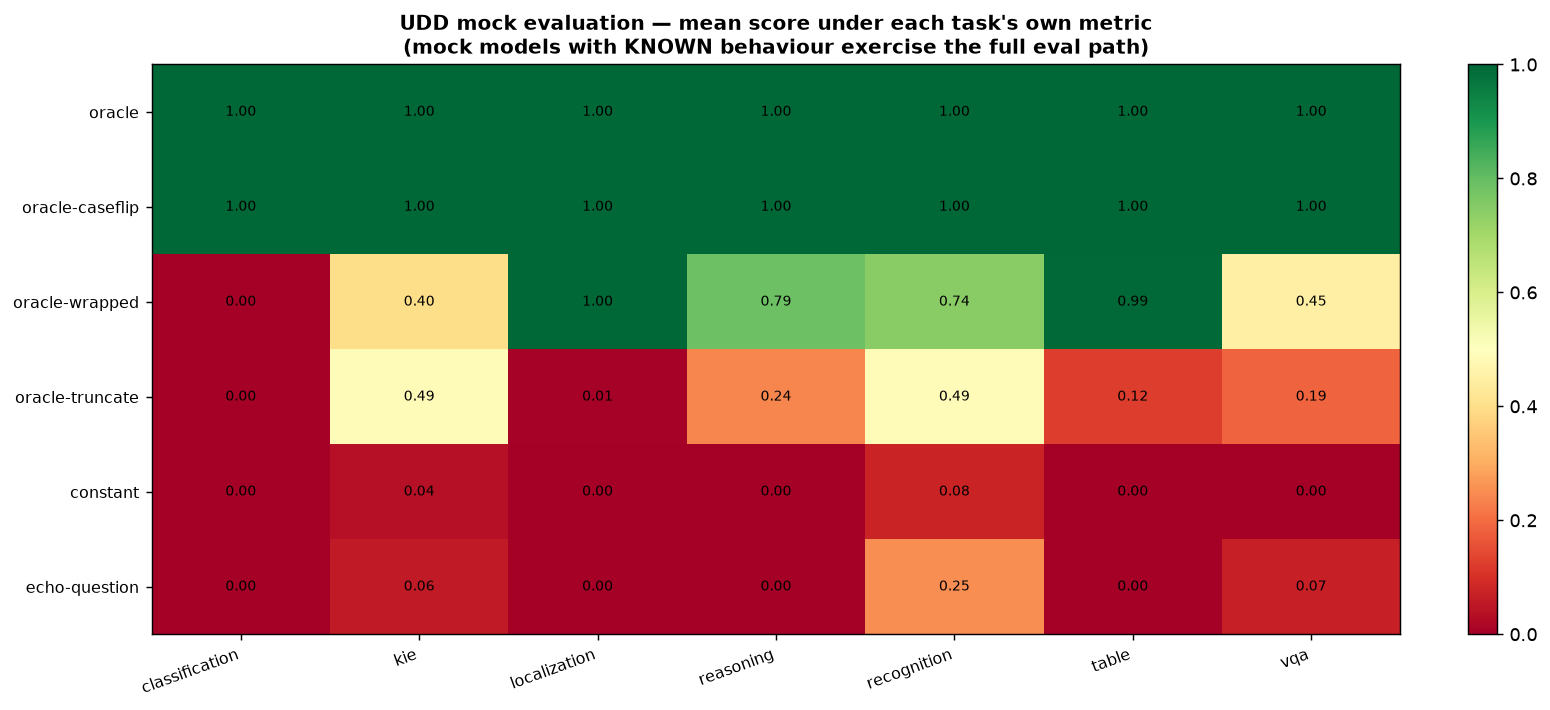

In [7]:
r = subprocess.run([sys.executable, "scripts/mock_eval_udd.py"], cwd=ROOT,
                   capture_output=True, text=True)
print(r.stdout[-300:]); assert r.returncode == 0, "mock eval sanity failed"
from IPython.display import Image as IPyImage, display
display(IPyImage(str(ROOT / "docs/report/figures/udd_mock_eval.png")))

## 6. Run ALL the experiments (GPU required — skipped automatically without one)

With a GPU, every composed arm (A1–A6) trains directly — no dry-run first — each at its family's
**full equal-N budget** (`--count 0` default: ALL the images the smallest arm of the family
supports), and evaluates BOTH the synthetic probe suite and the UDD public heldout; results land
in `docs/results/udd_ablation_results.json` under `U-<arm>`.

The default base (LFM2.5-VL) needs `transformers>=5`, while the repo's `[models]` extra pins `<5`
for the remote-code comparison sweep — so on a fresh Colab this cell upgrades transformers first.
`run_udd_ablation` runs as a subprocess, so the upgrade takes effect without restarting the kernel.


In [8]:
if has_gpu:
    # GUARANTEE the 2025-26 stack (same pattern as the finetune notebooks): LFM2.5-VL/Qwen3.5
    # need transformers>=5, and transformers 5.x rejects Colab's preinstalled torchao 0.10
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                    "transformers>=5", "torchao>=0.16.0", "accelerate"], check=True)
    # capture the child's output and echo its TAIL so a failure's reason lands right here,
    # not thousands of scrolled lines up
    r = subprocess.run([sys.executable, "scripts/run_udd_ablation.py",
                        "--arm", "A1", "A2", "A3", "A4", "A5", "A6",
                        "--steps", "300"], cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-3000:])
    if r.returncode != 0:
        print("=== FAILED (exit", r.returncode, ") — stderr tail ===")
        print(r.stderr[-3000:])
        raise RuntimeError("run_udd_ablation failed — see the stderr tail above for the reason")
else:
    print("no GPU — skipping training. On a T4/Colab, run:")
    print("  python scripts/run_udd_ablation.py --arm A1 A2 A3 A4 A5 A6 --steps 300"
          "   # --count 0 = ALL images")


no GPU — skipping training. On a T4/Colab, run:
  python scripts/run_udd_ablation.py --arm A1 A2 A3 A4 A5 A6 --steps 300   # --count 0 = ALL images


## 7. Read results (once the GPU runs land)

In [9]:
found = False
for f in (ROOT / "docs/results/udd_ablation_results.json",
          ROOT / "docs/results/udd_ablation_smoke.json"):
    if f.exists():
        for model, arms in json.loads(f.read_text()).get("models", {}).items():
            for arm, payload in arms.items():
                cap = payload.get("probes", {}).get("capability", {}).get("score")
                print(f"{f.stem:26} {model:16} {arm:22} capability={cap}")
                found = True
if not found:
    print("no results yet — section 6 (GPU) has not run; the wiring above is verified regardless.")


udd_ablation_smoke         smolvlm-256m     U-A1_spotting_on       capability=0.4389


## 8. Before/after cross-capability comparison — the point of every arm

A factor is only "helpful" if it moves the **whole capability surface**, not just its own axis —
e.g. if localization supervision helps, overall OCR/KIE/VQA on the heldout should improve, not just
grounding IoU. `run_udd_ablation` therefore records, for every arm:

- `probes_before` — the UN-tuned base scored on the full suite (synthetic probes + UDD heldout)
- `probes` — the same suite after LoRA training on the arm
- `delta` — per-probe score deltas **and per-axis (task) deltas**
- `preds_before/` & `preds_after/` — per-sample predictions+scores, so you can inspect the exact
  examples that flipped

`--smoke` runs the ENTIRE arm ladder as a tiny train+validate (count=24, steps=8, 16 eval
samples/probe) — a wiring/before-after proof, not a measurement. On a T4 the full A1–A6 smoke is
~1–2h; `--models smolvlm-256m` makes single arms feasible even on CPU (slow). One CPU smoke run
(U-A1_spotting_on) is committed at `docs/results/udd_ablation_smoke.json`, so sections 9–10 render
even on a fresh clone.


In [10]:
if has_gpu:
    subprocess.run([sys.executable, "scripts/run_udd_ablation.py",
                    "--arm", "A1", "A2", "A3", "A4", "A5", "A6", "--smoke"], cwd=ROOT, check=True)
else:
    print("no GPU — smoke ladder skipped. Run on a T4/Colab:")
    print("  python scripts/run_udd_ablation.py --arm A1 A2 A3 A4 A5 A6 --smoke")
    print("or a single arm on CPU (slow):")
    print("  python scripts/run_udd_ablation.py --arm A1 --smoke --models smolvlm-256m")

no GPU — smoke ladder skipped. Run on a T4/Colab:
  python scripts/run_udd_ablation.py --arm A1 A2 A3 A4 A5 A6 --smoke
or a single arm on CPU (slow):
  python scripts/run_udd_ablation.py --arm A1 --smoke --models smolvlm-256m


## 9. Full comparison — before → after on the WHOLE suite, per arm

Both granularities, for every arm that has a before/after run (full results are preferred; the
committed CPU smoke fills in otherwise):

1. **coarse** — one row per arm: `before → after (Δ)` for each of the four suites
   (`capability` = synthetic hypothesis probes, `spatial`/`realistic` = controlled probe suites,
   `heldout` = the public UDD held-out fold);
2. **fine-grained** — a `suite:axis` heatmap of deltas, down to individual task/probe axes.


model / arm                                               capability                     spatial                   realistic                     heldout
--------------------------------------------------------------------------------------------------------------------------------------------------------
smolvlm-256m/U-A1_spotting_on                   0.439→0.439 (+0.000)        0.400→0.333 (-0.067)        0.007→0.007 (+0.000)        0.410→0.412 (+0.003)


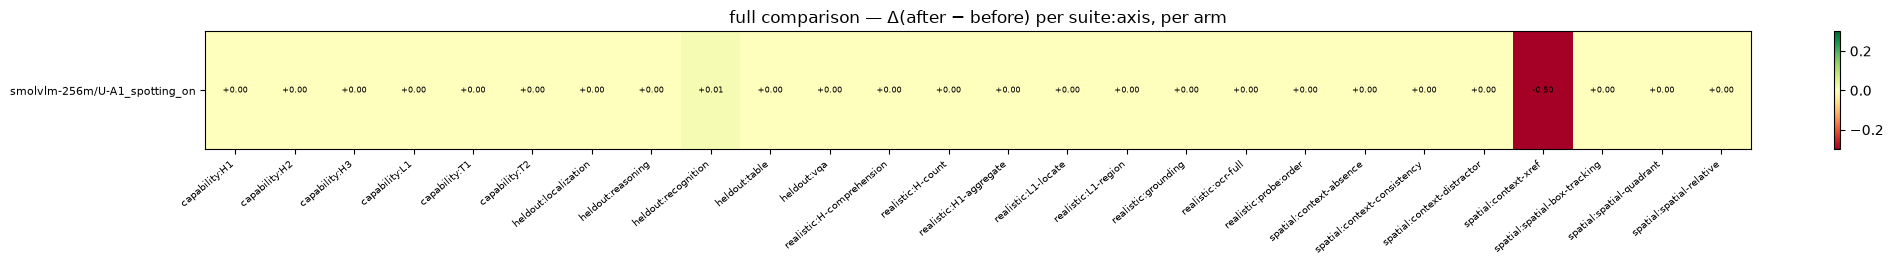

In [11]:
import matplotlib.pyplot as plt

SUITES = ("capability", "spatial", "realistic", "heldout")
runs = {}                              # (model, arm) -> payload; first file wins = full > smoke
for f in (ROOT / "docs/results/udd_ablation_results.json",
          ROOT / "docs/results/udd_ablation_smoke.json"):
    if f.exists():
        for model, arms in json.loads(f.read_text()).get("models", {}).items():
            for arm, p in arms.items():
                if "delta" in p:
                    runs.setdefault((model, arm), p)

if not runs:
    print("no before/after runs yet — run section 8 (or the CPU smoke) first.")
else:
    items = sorted(runs.items())
    # 1) coarse: per-suite before -> after (delta)
    hdr = f"{'model / arm':40}" + "".join(f"{s:>28}" for s in SUITES)
    print(hdr); print("-" * len(hdr))
    for (model, arm), p in items:
        cells = []
        for s in SUITES:
            b = p.get("probes_before", {}).get(s, {}).get("score")
            a = p.get("probes", {}).get(s, {}).get("score")
            cells.append("—" if b is None or a is None else f"{b:.3f}→{a:.3f} ({a - b:+.3f})")
        print(f"{model}/{arm}"[:40].ljust(40) + "".join(f"{c:>28}" for c in cells))

    # 2) fine-grained: suite:axis heatmap of deltas
    axes_keys = sorted({(s, ax) for _, p in items
                        for s in SUITES for ax in p["delta"].get(s, {}).get("by_axis", {})})
    M_ = [[p["delta"].get(s, {}).get("by_axis", {}).get(ax, 0.0) for s, ax in axes_keys]
          for _, p in items]
    fig, ax = plt.subplots(figsize=(0.62 * len(axes_keys) + 3, 0.55 * len(items) + 2.2))
    im = ax.imshow(M_, cmap="RdYlGn", vmin=-0.3, vmax=0.3, aspect="auto")
    ax.set_xticks(range(len(axes_keys)))
    ax.set_xticklabels([f"{s}:{a}" for s, a in axes_keys], rotation=40, ha="right", fontsize=7)
    ax.set_yticks(range(len(items)))
    ax.set_yticklabels([f"{m}/{a}" for (m, a), _ in items], fontsize=8)
    for i in range(len(items)):
        for j in range(len(axes_keys)):
            ax.text(j, i, f"{M_[i][j]:+.2f}", ha="center", va="center", fontsize=6)
    ax.set_title("full comparison — Δ(after − before) per suite:axis, per arm")
    fig.colorbar(im, fraction=0.02); plt.tight_layout(); plt.show()


## 10. The examples that flipped — inspect WHY an arm helped or hurt

For any arm with saved predictions, join `preds_before` and `preds_after` by sample id and rank by
score change: the top rows are the concrete examples where the factor changed the model's behaviour
(e.g. a localization-trained model now reading a field it previously missed).

flipped examples for smolvlm-256m / U-A1_spotting_on:



Δ+0.04  [recognition] Transcribe all the text in the image. Answer with the text only.
   gold:   ['현칠제 현을 영 현으로 관 할하였다. 1018년에 금주의 속현으로 병 합되었다 가 뒤에 감무가 파견되 면서 독립되었 다. 1274년과 1 281년에 원나라 와 고려 연합군 의']
   before: '[].'  (score 0.01)
   after:  '[제안제진, 제안제진, 제안제진, 제안제진, 제안제�'  (score 0.05)


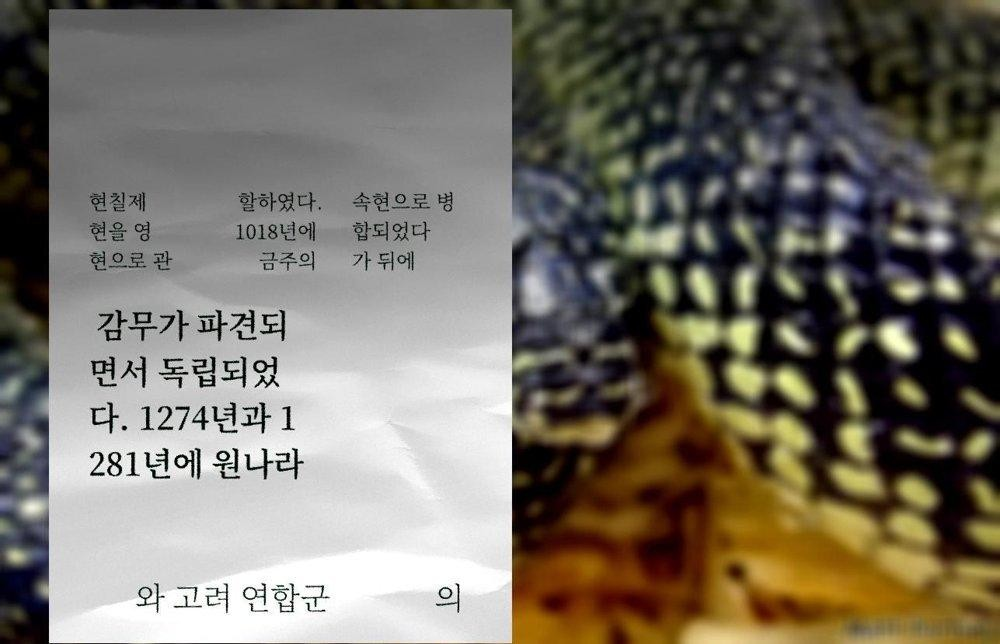


Δ+0.00  [vqa] Is Python a good duct tape language?
   gold:   ['Python is a horrible duct tape language.']
   before: 'Yes, Python is a good duct tape language.'  (score 0.71)
   after:  'Yes, Python is a good duct tape language.'  (score 0.71)


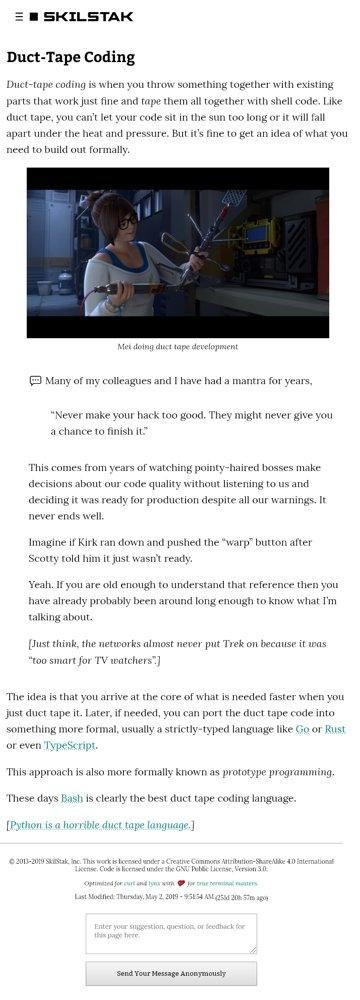


Δ+0.00  [reasoning] What attributed to settlements and reductions to unrecognized tax benefits?
   gold:   ['The settlements and reductions to unrecognized tax benefits for tax positions of prior years were primarily attributable to u.s. federal and state tax matters, non-u.s. audits and impacts due to lapse of statute of limitations.']
   before: 'The settlements and reductions to unrecognized tax benefits are attributable to the collec'  (score 0.00)
   after:  'The settlements and reductions to unrecognized tax benefits are attributable to the collec'  (score 0.00)


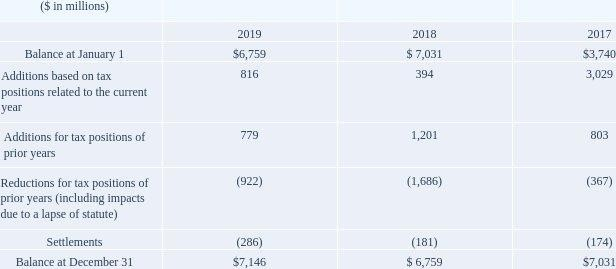


Δ+0.00  [vqa] Is there a person in the image?
   gold:   ['yes']
   before: 'Yes, there is a person sitting on a sofa in the image.'  (score 0.00)
   after:  'Yes, there is a person sitting on a sofa in the image.'  (score 0.00)

Δ+0.00  [recognition] Convert the formula in the image to LaTeX. Answer with the LaTeX only.
   gold:   ['\\begin{align*}i{\\gamma}^{\\mu}({\\partial}_{\\mu}+ieA_{\\mu}){\\psi}=0 \\end{align*}']
   before: '\\[ i\\dot{u} + i\\dot{a}u = 0 \\]'  (score 0.17)
   after:  '\\[ i\\dot{u} + i\\dot{a}u = 0 \\]'  (score 0.17)


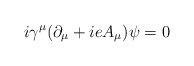

In [12]:
from IPython.display import Image as IPyImage, display

def flipped_examples(payload, probe="heldout", k=5):
    pd_ = Path(payload["preds_dir"])
    def load(phase):
        f = pd_ / f"preds_{phase}" / f"{probe}.jsonl"
        return {r["sample_id"]: r for r in map(json.loads, f.read_text().splitlines())}
    before, after = load("before"), load("after")
    rows = sorted(((after[sid]["score"] - before[sid]["score"], sid)
                   for sid in before if sid in after), key=lambda t: -abs(t[0]))
    for d, sid in rows[:k]:
        b, a = before[sid], after[sid]
        print(f"Δ{d:+.2f}  [{b.get('answer_type')}] {b['question'][:90]}")
        print(f"   gold:   {b['answers'][:2]}")
        print(f"   before: {b['prediction'][:90]!r}  (score {b['score']:.2f})")
        print(f"   after:  {a['prediction'][:90]!r}  (score {a['score']:.2f})")
        if Path(b.get("image_path", "")).exists():
            display(IPyImage(b["image_path"], width=380))
        print()

shown = False
for f in (ROOT / "docs/results/udd_ablation_results.json",
          ROOT / "docs/results/udd_ablation_smoke.json"):
    if f.exists() and not shown:
        for model, arms in json.loads(f.read_text()).get("models", {}).items():
            for arm, p in arms.items():
                if "preds_dir" in p and Path(p["preds_dir"]).exists() and not shown:
                    print(f"flipped examples for {model} / {arm}:\n")
                    flipped_examples(p); shown = True
if not shown:
    print("no runs with saved predictions yet — run section 8 first.")
